In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set style for plots
plt.style.use('default')
sns.set_palette('husl')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:

df = pd.read_csv('../data/processed/bigbasket_cleaned.csv')

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')

print(f'\nData types:')
print(df.dtypes)

Dataset loaded successfully!
Shape: 27,200 rows × 15 columns

Columns: ['product', 'category', 'sub_category', 'brand', 'sale_price', 'market_price', 'type', 'rating', 'description', 'is_price_anomaly', 'discount_amount', 'discount_pct', 'price_segment', 'is_discounted', 'rating_segment']

Data types:
product                 str
category                str
sub_category            str
brand                   str
sale_price          float64
market_price        float64
type                    str
rating              float64
description             str
is_price_anomaly       bool
discount_amount     float64
discount_pct        float64
price_segment           str
is_discounted          bool
rating_segment          str
dtype: object


## 3. Analysis 1: Basic Descriptive Statistics

Get an overview of the numerical columns to understand the data distribution.

In [32]:

numerical_cols = ['sale_price', 'market_price', 'rating', 'discount_amount', 'discount_pct']

print('Stats of the Numerical Columns')
print('=' * 50)
desc_stats = df[numerical_cols].describe()
print(desc_stats)

print('\nKEY INSIGHTS:')
print(f'- Average sale price: ₹{df["sale_price"].mean():.2f}')
print(f'- Average rating: {df["rating"].mean():.2f}/5.0')
print(f'- Products with discounts: {df["is_discounted"].sum():,} ({df["is_discounted"].mean()*100:.1f}%)')
print(f'- Average discount percentage: {df["discount_pct"].mean():.1f}%')
print(f'- Price range: ₹{df["sale_price"].min():.2f} - ₹{df["sale_price"].max():.2f}')

Stats of the Numerical Columns
       sale_price  market_price   rating  discount_amount  discount_pct
count    27200.00      27200.00 27200.00         27200.00      27200.00
mean       320.95        380.36     3.99            59.42         11.85
std        486.90        582.37     0.61           170.01         14.65
min          2.45          3.00     1.00             0.00          0.00
25%         95.00        100.00     3.90             0.00          0.00
50%        190.00        220.00     4.10             6.00          5.00
75%        351.00        425.00     4.20            51.00         20.00
max      12500.00      12500.00     5.00          4320.00         83.67

KEY INSIGHTS:
- Average sale price: ₹320.95
- Average rating: 3.99/5.0
- Products with discounts: 15,046 (55.3%)
- Average discount percentage: 11.8%
- Price range: ₹2.45 - ₹12500.00


## 4. Analysis 2: Category Distribution

Analyze the distribution of products across different categories to understand market focus.

CATEGORY DISTRIBUTION
                          Count  Percentage
category                                   
Beauty & Hygiene           7682       28.24
Gourmet & World Food       4677       17.19
Kitchen, Garden & Pets     3457       12.71
Snacks & Branded Foods     2810       10.33
Foodgrains, Oil & Masala   2673        9.83
Cleaning & Household       2650        9.74
Beverages                   884        3.25
Bakery, Cakes & Dairy       850        3.12
Baby Care                   610        2.24
Fruits & Vegetables         557        2.05

Total categories: 11
Top category: Beauty & Hygiene (7,682 products)


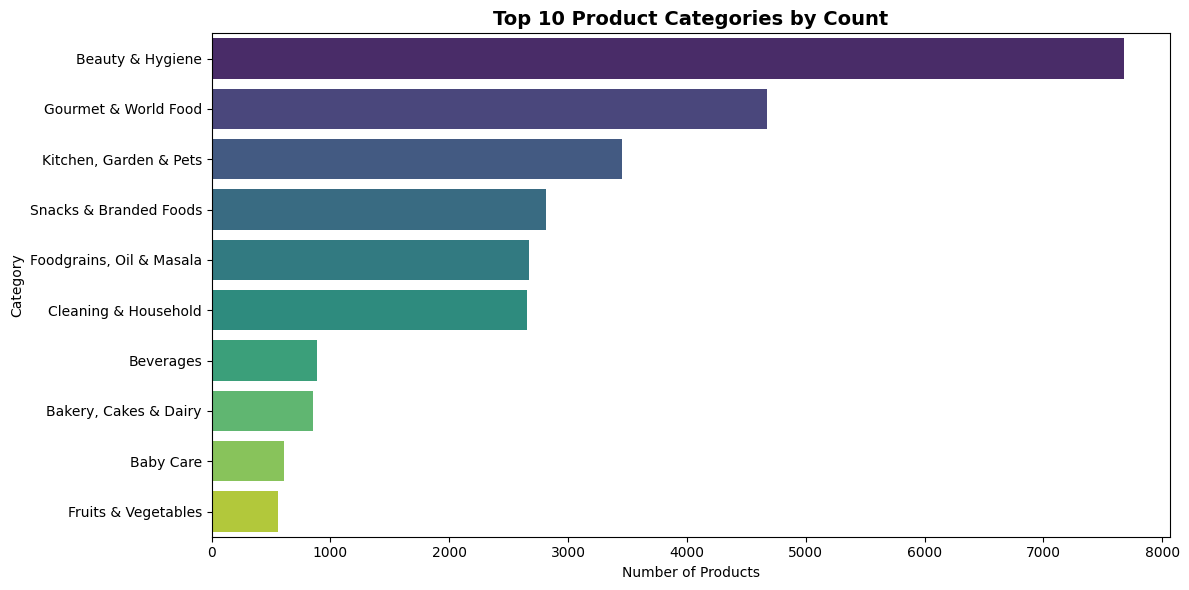


KEY INSIGHTS:
- Most represented category: Beauty & Hygiene
- Top 3 categories represent 58.1% of all products
- Average products per category: 2473


In [33]:

category_counts = df['category'].value_counts()
category_pct = df['category'].value_counts(normalize=True) * 100

print('CATEGORY DISTRIBUTION')
print('=' * 30)
category_summary = pd.DataFrame({
    'Count': category_counts,
    'Percentage': category_pct.round(2)
})
print(category_summary.head(10))

print(f'\nTotal categories: {df["category"].nunique()}')
print(f'Top category: {category_counts.index[0]} ({category_counts.iloc[0]:,} products)')


plt.figure(figsize=(12, 6))
top_10_categories = category_counts.head(10)
sns.barplot(x=top_10_categories.values, y=top_10_categories.index, palette='viridis')
plt.title('Top 10 Product Categories by Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Most represented category: {category_counts.index[0]}')
print(f'- Top 3 categories represent {category_pct.head(3).sum():.1f}% of all products')
print(f'- Average products per category: {category_counts.mean():.0f}')

## 5. Analysis 3: Top Brands Analysis

Identify the most prominent brands in the marketplace by product count.

TOP BRANDS BY PRODUCT COUNT
                  Count  Percentage
brand                              
Fresho              638        2.35
Bb Royal            539        1.98
Bb Home             428        1.57
Dp                  243        0.89
Fresho Signature    170        0.62
Bb Combo            167        0.61
Amul                153        0.56
Inatur              142        0.52
Himalaya            141        0.52
Dabur               137        0.50
Gooddiet            134        0.49
Nike                122        0.45
Biotique            115        0.42
Colgate             107        0.39
Cello               106        0.39

Total unique brands: 2313
Top brand: Fresho (638 products)


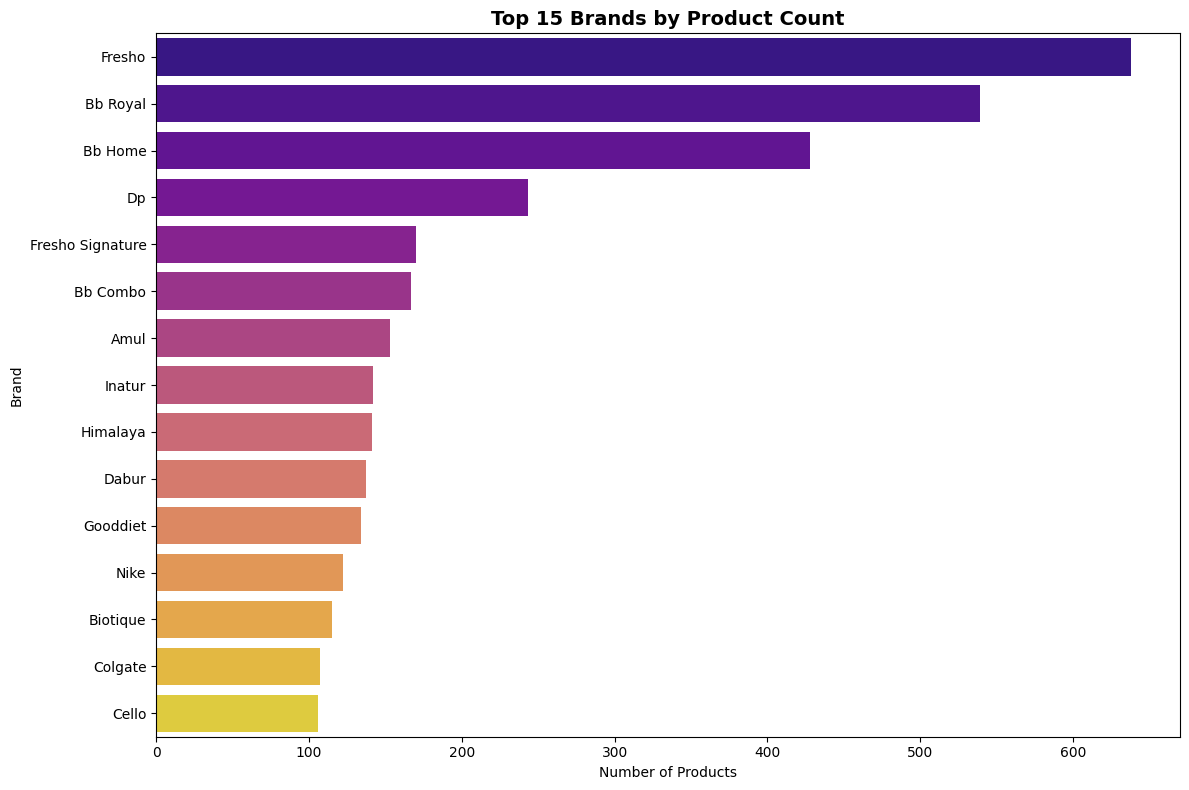


KEY INSIGHTS:
- Top brand dominates with 638 products
- Top 5 brands represent 7.4% of all products
- Average products per brand: 11.8


In [34]:

brand_counts = df['brand'].value_counts()
brand_pct = df['brand'].value_counts(normalize=True) * 100

print('TOP BRANDS BY PRODUCT COUNT')
print('=' * 30)
brand_summary = pd.DataFrame({
    'Count': brand_counts.head(15),
    'Percentage': brand_pct.head(15).round(2)
})
print(brand_summary)

print(f'\nTotal unique brands: {df["brand"].nunique()}')
print(f'Top brand: {brand_counts.index[0]} ({brand_counts.iloc[0]:,} products)')

# Visualization
plt.figure(figsize=(12, 8))
top_15_brands = brand_counts.head(15)
sns.barplot(x=top_15_brands.values, y=top_15_brands.index, palette='plasma')
plt.title('Top 15 Brands by Product Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Top brand dominates with {brand_counts.iloc[0]:,} products')
print(f'- Top 5 brands represent {brand_pct.head(5).sum():.1f}% of all products')
print(f'- Average products per brand: {brand_counts.mean():.1f}')

## 6. Analysis 4: Price Distribution Analysis

Examine the distribution of sale prices to understand pricing patterns.

PRICE DISTRIBUTION ANALYSIS
Sale Price Statistics:
count   27200.00
mean      320.95
std       486.90
min         2.45
25%        95.00
50%       190.00
75%       351.00
max     12500.00
Name: sale_price, dtype: float64

Price Segment Distribution:
               Count  Percentage
price_segment                   
Mid-range      15449       56.80
Budget          7717       28.37
Premium         4034       14.83


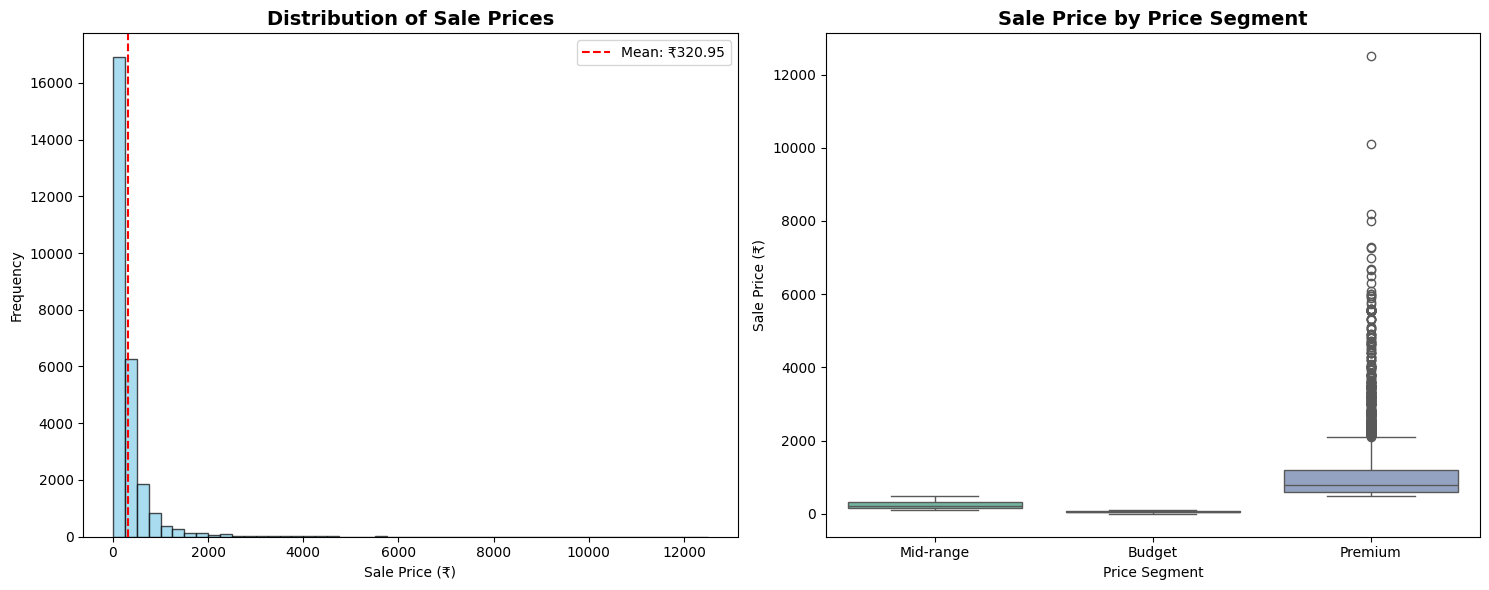


KEY INSIGHTS:
- Most products fall in Mid-range segment (56.8%)
- Price range: ₹2.45 - ₹12500.00
- Median price: ₹190.00
- 75% of products cost ₹351.00 or less


In [17]:
# Price distribution analysis
print('PRICE DISTRIBUTION ANALYSIS')
print('=' * 30)

# Price statistics
price_stats = df['sale_price'].describe()
print('Sale Price Statistics:')
print(price_stats)

# Price segments distribution
price_segment_dist = df['price_segment'].value_counts()
price_segment_pct = df['price_segment'].value_counts(normalize=True) * 100

print(f'\nPrice Segment Distribution:')
segment_summary = pd.DataFrame({
    'Count': price_segment_dist,
    'Percentage': price_segment_pct.round(2)
})
print(segment_summary)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
ax1.hist(df['sale_price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Sale Prices', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sale Price (₹)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['sale_price'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df["sale_price"].mean():.2f}')
ax1.legend()

# Box plot by price segment
sns.boxplot(x='price_segment', y='sale_price', data=df, ax=ax2, palette='Set2')
ax2.set_title('Sale Price by Price Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Price Segment')
ax2.set_ylabel('Sale Price (₹)')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Most products fall in {price_segment_dist.index[0]} segment ({price_segment_pct.iloc[0]:.1f}%)')
print(f'- Price range: ₹{df["sale_price"].min():.2f} - ₹{df["sale_price"].max():.2f}')
print(f'- Median price: ₹{df["sale_price"].median():.2f}')
print(f'- 75% of products cost ₹{df["sale_price"].quantile(0.75):.2f} or less')

## 7. Analysis 5: Rating Distribution Analysis

Analyze customer ratings to understand product quality perception.

RATING DISTRIBUTION ANALYSIS
Rating Statistics:
count   27200.00
mean        3.99
std         0.61
min         1.00
25%         3.90
50%         4.10
75%         4.20
max         5.00
Name: rating, dtype: float64

Rating Segment Distribution:
                Count  Percentage
rating_segment                   
High            17452       64.16
Medium           7719       28.38
Low              2029        7.46


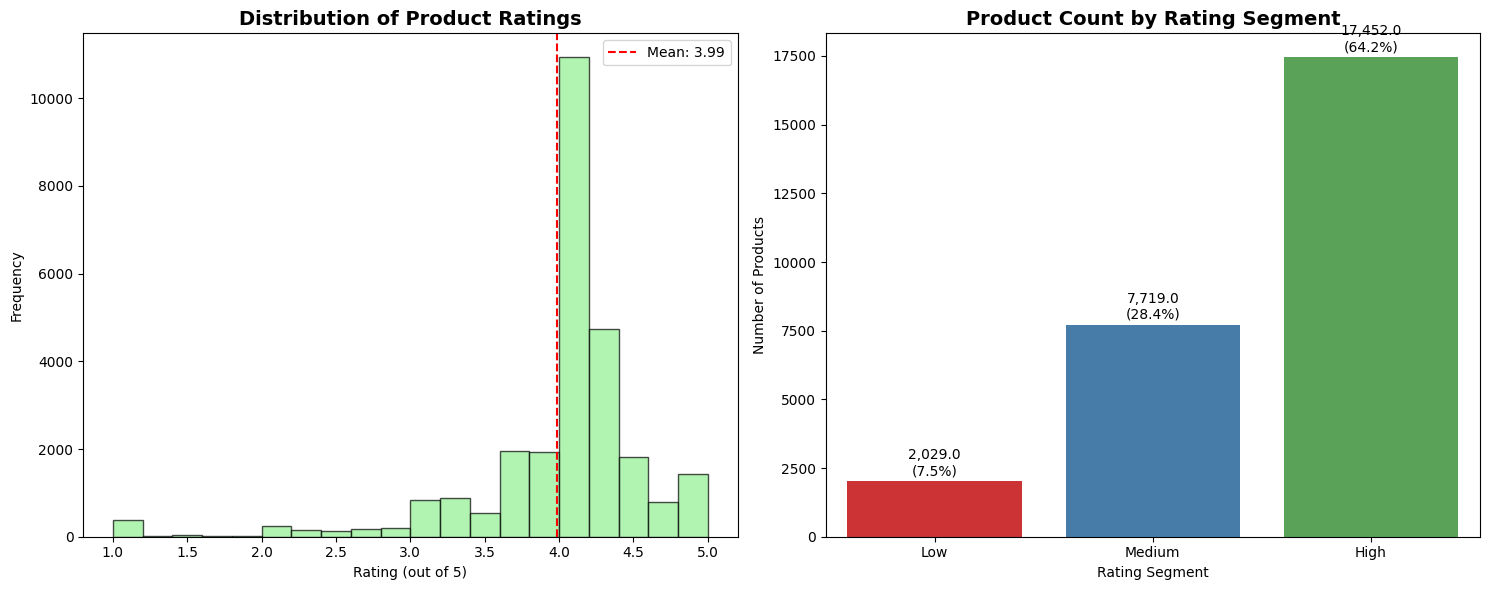


KEY INSIGHTS:
- Average rating: 3.99/5.0
- Most products have High ratings (64.2%)
- Rating range: 1.0 - 5.0
- 50% of products have rating ≥ 4.1


In [18]:
# Rating distribution analysis
print('RATING DISTRIBUTION ANALYSIS')
print('=' * 30)

# Rating statistics
rating_stats = df['rating'].describe()
print('Rating Statistics:')
print(rating_stats)

# Rating segments distribution
rating_segment_dist = df['rating_segment'].value_counts()
rating_segment_pct = df['rating_segment'].value_counts(normalize=True) * 100

print(f'\nRating Segment Distribution:')
rating_segment_summary = pd.DataFrame({
    'Count': rating_segment_dist,
    'Percentage': rating_segment_pct.round(2)
})
print(rating_segment_summary)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
ax1.hist(df['rating'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
ax1.set_title('Distribution of Product Ratings', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rating (out of 5)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
ax1.legend()

# Count plot by rating segment
sns.countplot(x='rating_segment', data=df, ax=ax2, palette='Set1', order=['Low', 'Medium', 'High'])
ax2.set_title('Product Count by Rating Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Rating Segment')
ax2.set_ylabel('Number of Products')

# Add percentage labels
for p in ax2.patches:
    height = p.get_height()
    ax2.text(p.get_x() + p.get_width()/2., height + 100,
             f'{height:,}\n({height/len(df)*100:.1f}%)',
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Average rating: {df["rating"].mean():.2f}/5.0')
print(f'- Most products have {rating_segment_dist.index[0]} ratings ({rating_segment_pct.iloc[0]:.1f}%)')
print(f'- Rating range: {df["rating"].min():.1f} - {df["rating"].max():.1f}')
print(f'- 50% of products have rating ≥ {df["rating"].median():.1f}')

## 8. Analysis 6: Discount Analysis

Examine discount patterns and their impact on pricing strategy.

DISCOUNT ANALYSIS
Total products: 27,200
Discounted products: 15,046 (55.3%)
Non-discounted products: 12,154 (44.7%)

Discount Statistics (for discounted products only):
       discount_amount  discount_pct
count         15046.00      15046.00
mean            107.41         21.41
std             217.01         13.53
min               0.10          0.20
25%              16.00         10.00
50%              44.85         20.00
75%             112.50         30.00
max            4320.00         83.67


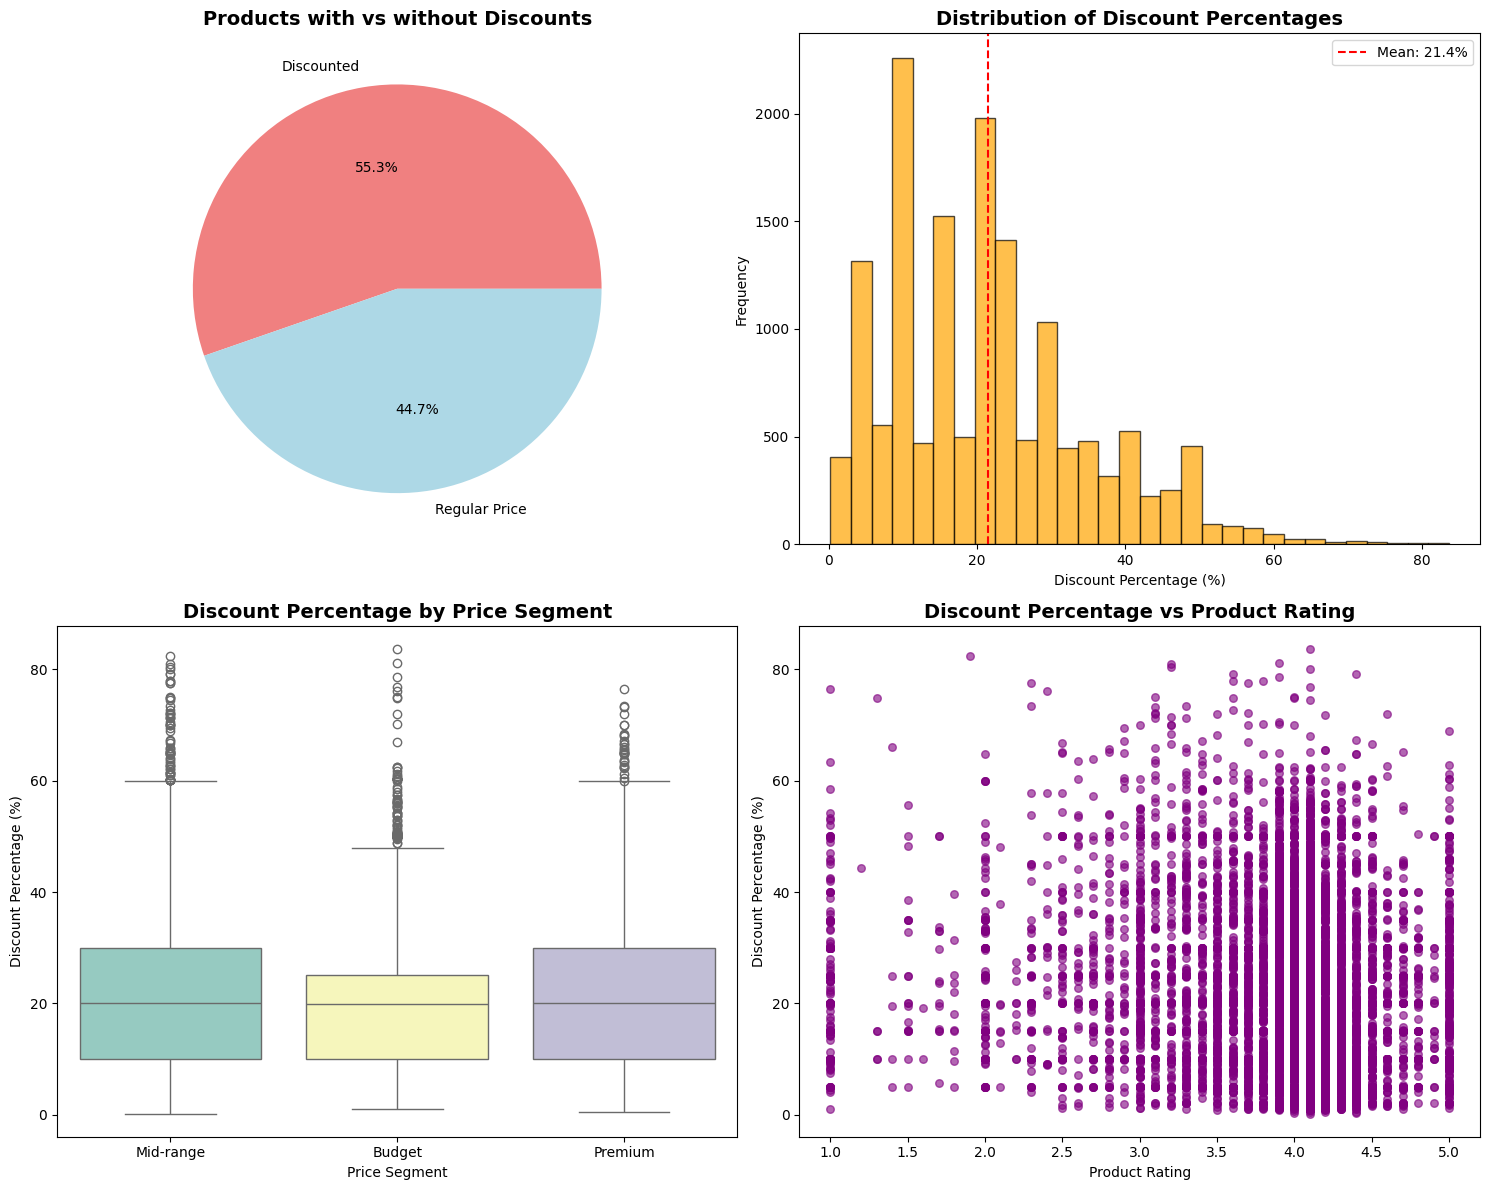


KEY INSIGHTS:
- 55.3% of products are discounted
- Average discount: 21.4%
- Maximum discount: 83.7%
- Most common discount range: 10.0% - 30.0%


In [19]:
# Discount analysis
print('DISCOUNT ANALYSIS')
print('=' * 20)

discounted_products = df[df['is_discounted'] == True]
non_discounted_products = df[df['is_discounted'] == False]

print(f'Total products: {len(df):,}')
print(f'Discounted products: {len(discounted_products):,} ({len(discounted_products)/len(df)*100:.1f}%)')
print(f'Non-discounted products: {len(non_discounted_products):,} ({len(non_discounted_products)/len(df)*100:.1f}%)')

print(f'\nDiscount Statistics (for discounted products only):')
discount_stats = discounted_products[['discount_amount', 'discount_pct']].describe()
print(discount_stats)

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Pie chart for discount vs no discount
discount_pie = [len(discounted_products), len(non_discounted_products)]
ax1.pie(discount_pie, labels=['Discounted', 'Regular Price'], autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
ax1.set_title('Products with vs without Discounts', fontsize=14, fontweight='bold')

# Histogram of discount percentages
ax2.hist(discounted_products['discount_pct'], bins=30, alpha=0.7, color='orange', edgecolor='black')
ax2.set_title('Distribution of Discount Percentages', fontsize=14, fontweight='bold')
ax2.set_xlabel('Discount Percentage (%)')
ax2.set_ylabel('Frequency')
ax2.axvline(discounted_products['discount_pct'].mean(), color='red', linestyle='--',
            label=f'Mean: {discounted_products["discount_pct"].mean():.1f}%')
ax2.legend()

# Box plot of discount by price segment
sns.boxplot(x='price_segment', y='discount_pct', data=discounted_products, ax=ax3, palette='Set3')
ax3.set_title('Discount Percentage by Price Segment', fontsize=14, fontweight='bold')
ax3.set_xlabel('Price Segment')
ax3.set_ylabel('Discount Percentage (%)')

# Scatter plot of discount vs rating
ax4.scatter(discounted_products['rating'], discounted_products['discount_pct'],
           alpha=0.6, color='purple', s=30)
ax4.set_title('Discount Percentage vs Product Rating', fontsize=14, fontweight='bold')
ax4.set_xlabel('Product Rating')
ax4.set_ylabel('Discount Percentage (%)')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- {len(discounted_products)/len(df)*100:.1f}% of products are discounted')
print(f'- Average discount: {discounted_products["discount_pct"].mean():.1f}%')
print(f'- Maximum discount: {discounted_products["discount_pct"].max():.1f}%')
print(f'- Most common discount range: {discounted_products["discount_pct"].quantile(0.25):.1f}% - {discounted_products["discount_pct"].quantile(0.75):.1f}%')

## 9. Analysis 7: Price vs Rating Correlation

Investigate the relationship between product pricing and customer ratings.

PRICE VS RATING CORRELATION ANALYSIS
Correlation coefficient between sale price and rating: -0.036
This indicates a very weak negative correlation.

Average Rating by Price Segment:
               mean  median  count
price_segment                     
Budget         4.04    4.10   7717
Mid-range      3.98    4.10  15449
Premium        3.92    4.10   4034


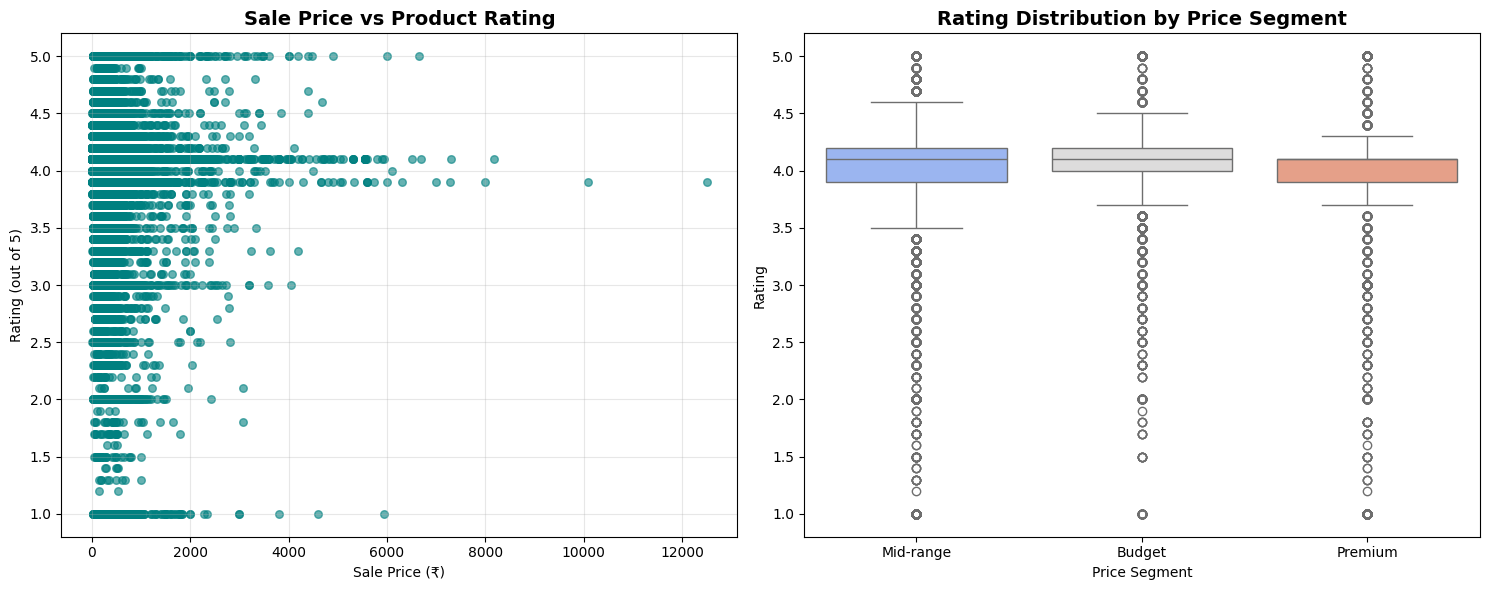

In [29]:
# Price vs Rating correlation analysis
print('PRICE VS RATING CORRELATION ANALYSIS')
print('=' * 40)

# Calculate correlation
correlation = df['sale_price'].corr(df['rating'])
print(f'Correlation coefficient between sale price and rating: {correlation:.3f}')

# Correlation interpretation
if abs(correlation) < 0.1:
    corr_strength = "very weak"
elif abs(correlation) < 0.3:
    corr_strength = "weak"
elif abs(correlation) < 0.5:
    corr_strength = "moderate"
elif abs(correlation) < 0.7:
    corr_strength = "strong"
else:
    corr_strength = "very strong"

corr_direction = "positive" if correlation > 0 else "negative"
print(f'This indicates a {corr_strength} {corr_direction} correlation.')

# Analysis by price segments
price_rating_analysis = df.groupby('price_segment').agg({
    'rating': ['mean', 'median', 'count'],
    'sale_price': ['mean', 'min', 'max']
}).round(2)

print(f'\nAverage Rating by Price Segment:')
print(price_rating_analysis['rating'])

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
ax1.scatter(df['sale_price'], df['rating'], alpha=0.6, color='teal', s=30)
ax1.set_title('Sale Price vs Product Rating', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sale Price (₹)')
ax1.set_ylabel('Rating (out of 5)')
ax1.grid(True, alpha=0.3)

# Box plot by price segment
sns.boxplot(x='price_segment', y='rating', data=df, ax=ax2, palette='coolwarm')
ax2.set_title('Rating Distribution by Price Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Price Segment')
ax2.set_ylabel('Rating')

plt.tight_layout()
plt.show()

# print(df['price_segment'])


## 10. Analysis 8: Most Expensive Categories

Identify categories with the highest average prices to understand premium product segments.

MOST EXPENSIVE CATEGORIES ANALYSIS
Top 10 Most Expensive Categories (by Average Sale Price):
                         sale_price                       market_price
                               mean median      max count         mean
category                                                              
Baby Care                    534.95 319.66  3299.00   610       596.75
Kitchen, Garden & Pets       508.79 299.00 12500.00  3457       663.52
Beauty & Hygiene             416.98 243.60  8184.44  7682       491.86
Gourmet & World Food         320.11 240.00  7299.00  4677       358.72
Eggs, Meat & Fish            288.90 230.00  2249.10   350       325.84
Beverages                    239.97 175.70  3480.00   884       272.49
Cleaning & Household         226.48 159.00  3600.00  2650       262.44
Foodgrains, Oil & Masala     193.28 100.00  4099.00  2673       230.29
Bakery, Cakes & Dairy        142.84 109.00  1108.00   850       157.89
Snacks & Branded Foods       129.67  87.56  1950.00  28

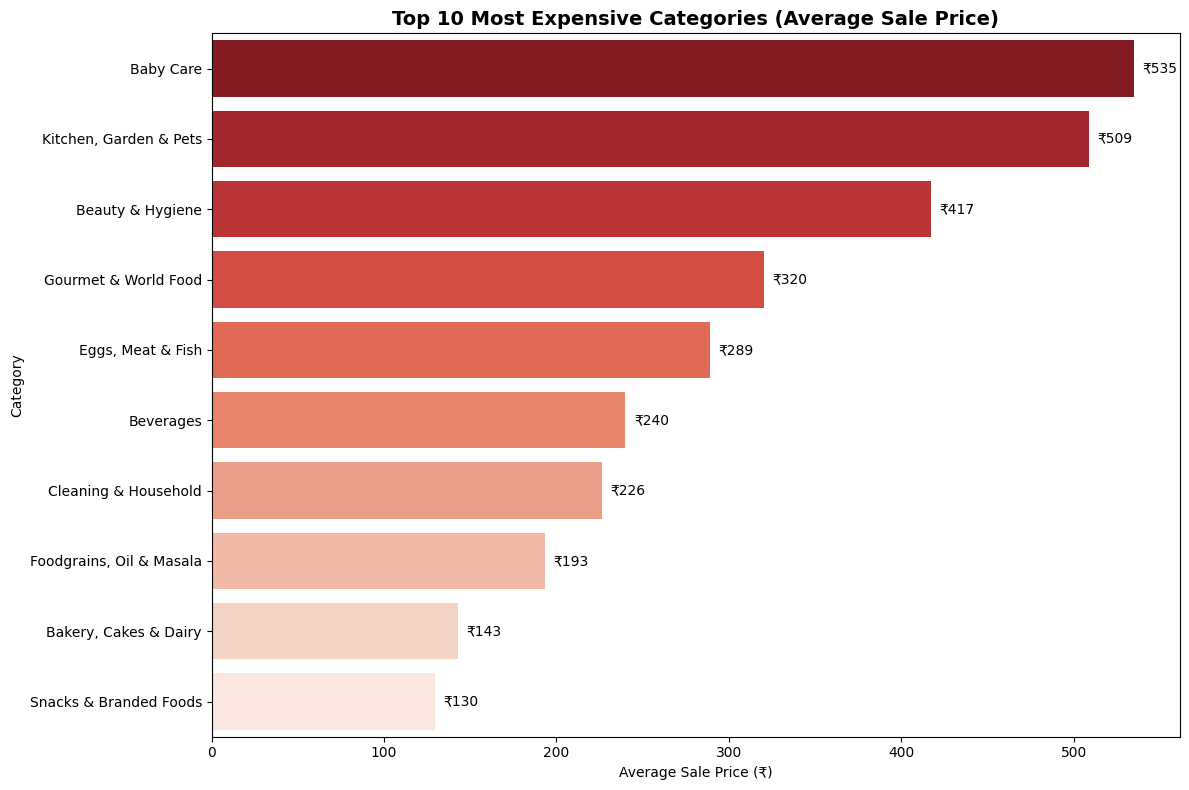


KEY INSIGHTS:
- Most expensive category: Baby Care (₹534.95 avg)
- Price range across categories: ₹50.89 - ₹534.95
- Top 3 premium categories: Baby Care, Kitchen, Garden & Pets, Beauty & Hygiene


In [22]:
# Most expensive categories analysis
print('MOST EXPENSIVE CATEGORIES ANALYSIS')
print('=' * 35)

# Calculate average prices by category
category_prices = df.groupby('category').agg({
    'sale_price': ['mean', 'median', 'max', 'count'],
    'market_price': 'mean'
}).round(2)

# Sort by average sale price
category_prices_sorted = category_prices.sort_values(('sale_price', 'mean'), ascending=False)

print('Top 10 Most Expensive Categories (by Average Sale Price):')
top_expensive = category_prices_sorted.head(10)
print(top_expensive)

# Visualization
plt.figure(figsize=(12, 8))
top_10_expensive = category_prices_sorted.head(10)
categories = top_10_expensive.index
avg_prices = top_10_expensive[('sale_price', 'mean')]

sns.barplot(x=avg_prices, y=categories, palette='Reds_r')
plt.title('Top 10 Most Expensive Categories (Average Sale Price)', fontsize=14, fontweight='bold')
plt.xlabel('Average Sale Price (₹)')
plt.ylabel('Category')

# Add price labels
for i, v in enumerate(avg_prices):
    plt.text(v + 5, i, f'₹{v:.0f}', va='center')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Most expensive category: {top_expensive.index[0]} (₹{top_expensive[("sale_price", "mean")].iloc[0]:.2f} avg)')
print(f'- Price range across categories: ₹{category_prices_sorted[("sale_price", "mean")].min():.2f} - ₹{category_prices_sorted[("sale_price", "mean")].max():.2f}')
print(f'- Top 3 premium categories: {", ".join(top_expensive.index[:3])}')

## 11. Analysis 9: Brand Performance by Rating

Evaluate brand performance based on average customer ratings.

BRAND PERFORMANCE BY RATING ANALYSIS
Top 10 Highest Rated Brands (min 10 products):
                  rating           
                    mean count  std
brand                              
Kaadoo              4.59    13 0.55
Vahdam              4.47    59 0.38
The Whole Truth     4.47    14 0.48
Bobs Red Mill       4.44    14 0.45
Papergrid           4.43    10 0.57
Morpheme Remedies   4.43    19 0.50
Purecult            4.42    12 0.43
Parachute           4.41    12 0.28
Tide                4.40    11 0.13
Selpak              4.38    21 0.48

Bottom 10 Lowest Rated Brands (min 10 products):
                     rating           
                       mean count  std
brand                                 
Mr.Copper King         3.15    14 1.02
Le Kaviraj             3.10    20 0.72
Love Beauty & Planet   3.06    10 1.32
Goeld                  3.06    12 0.84
Frestol                2.98    28 0.77
Nova                   2.87    23 0.89
Nanonine               2.81    20 1.07
Command 

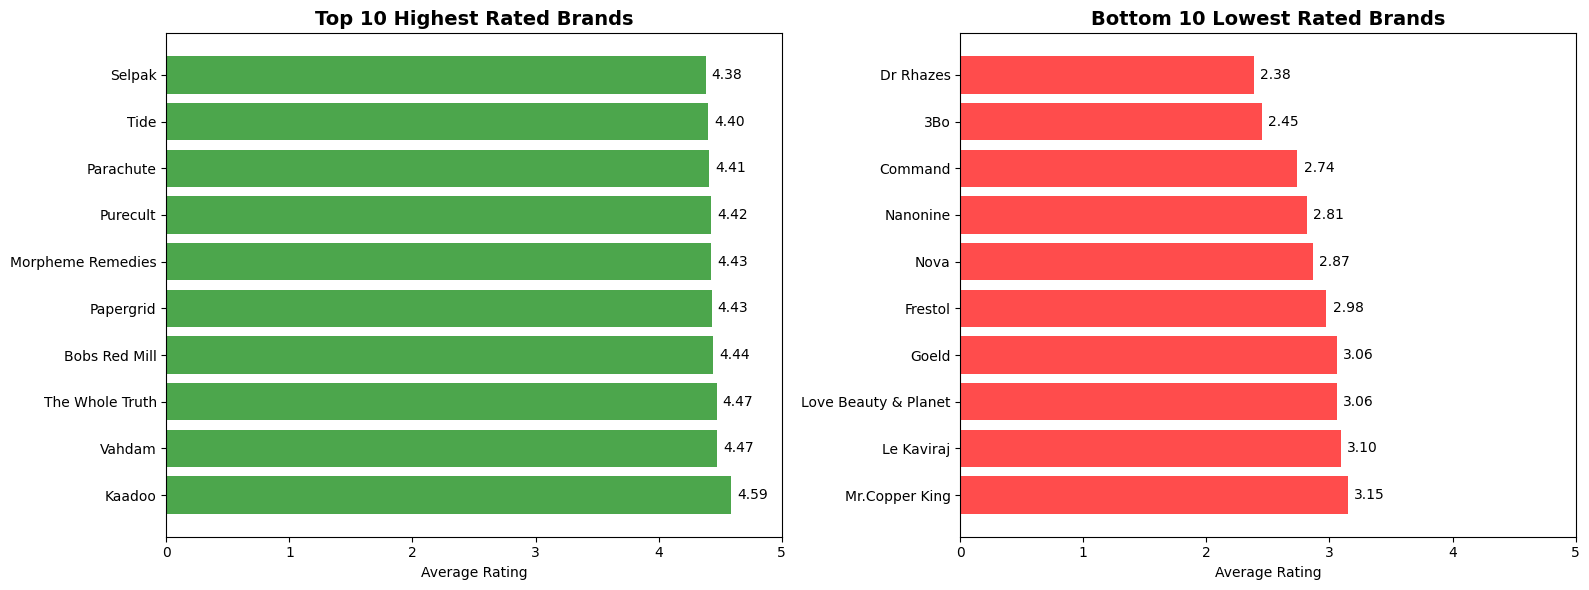


KEY INSIGHTS:
- Highest rated brand: Kaadoo (4.59/5.0)
- Lowest rated brand: Dr Rhazes (2.38/5.0)
- Rating range among reliable brands: 2.38 - 4.59
- Average rating across all brands: 3.96/5.0


In [23]:
# Brand performance by rating analysis
print('BRAND PERFORMANCE BY RATING ANALYSIS')
print('=' * 35)

# Calculate average ratings by brand (only brands with at least 10 products)
brand_ratings = df.groupby('brand').agg({
    'rating': ['mean', 'count', 'std']
}).round(3)

# Filter brands with at least 10 products for reliable statistics
reliable_brands = brand_ratings[brand_ratings[('rating', 'count')] >= 10]
reliable_brands_sorted = reliable_brands.sort_values(('rating', 'mean'), ascending=False)

print('Top 10 Highest Rated Brands (min 10 products):')
top_rated_brands = reliable_brands_sorted.head(10)
print(top_rated_brands)

print('\nBottom 10 Lowest Rated Brands (min 10 products):')
bottom_rated_brands = reliable_brands_sorted.tail(10)
print(bottom_rated_brands)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top rated brands
top_10_brands = reliable_brands_sorted.head(10)
brands_top = top_10_brands.index
ratings_top = top_10_brands[('rating', 'mean')]

ax1.barh(brands_top, ratings_top, color='green', alpha=0.7)
ax1.set_title('Top 10 Highest Rated Brands', fontsize=14, fontweight='bold')
ax1.set_xlabel('Average Rating')
ax1.set_xlim(0, 5)

# Add rating labels
for i, v in enumerate(ratings_top):
    ax1.text(v + 0.05, i, f'{v:.2f}', va='center')

# Bottom rated brands
bottom_10_brands = reliable_brands_sorted.tail(10)
brands_bottom = bottom_10_brands.index
ratings_bottom = bottom_10_brands[('rating', 'mean')]

ax2.barh(brands_bottom, ratings_bottom, color='red', alpha=0.7)
ax2.set_title('Bottom 10 Lowest Rated Brands', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Rating')
ax2.set_xlim(0, 5)

# Add rating labels
for i, v in enumerate(ratings_bottom):
    ax2.text(v + 0.05, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
print(f'- Highest rated brand: {top_rated_brands.index[0]} ({top_rated_brands[("rating", "mean")].iloc[0]:.2f}/5.0)')
print(f'- Lowest rated brand: {bottom_rated_brands.index[-1]} ({bottom_rated_brands[("rating", "mean")].iloc[-1]:.2f}/5.0)')
print(f'- Rating range among reliable brands: {reliable_brands_sorted[("rating", "mean")].min():.2f} - {reliable_brands_sorted[("rating", "mean")].max():.2f}')
print(f'- Average rating across all brands: {reliable_brands[("rating", "mean")].mean():.2f}/5.0')

## 12. Analysis 10: Price Segments Deep Dive

Comprehensive analysis of different price segments and their characteristics.

PRICE SEGMENTS DEEP DIVE ANALYSIS
Comprehensive Analysis by Price Segment:
              sale_price                                rating         \
                   count    mean    min      max    std   mean median   
price_segment                                                           
Budget              7717   60.11   2.45   100.00  25.57   4.04   4.10   
Mid-range          15449  246.87 101.00   500.00 106.44   3.98   4.10   
Premium             4034 1103.62 500.39 12500.00 888.95   3.92   4.10   

              discount_pct       is_discounted  
                      mean   max          mean  
price_segment                                   
Budget                9.94 83.67          0.51  
Mid-range            12.52 82.51          0.57  
Premium              12.91 76.50          0.58  

Segment Distribution:
- Mid-range: 15,449 products (56.8%)
- Budget: 7,717 products (28.37%)
- Premium: 4,034 products (14.83%)


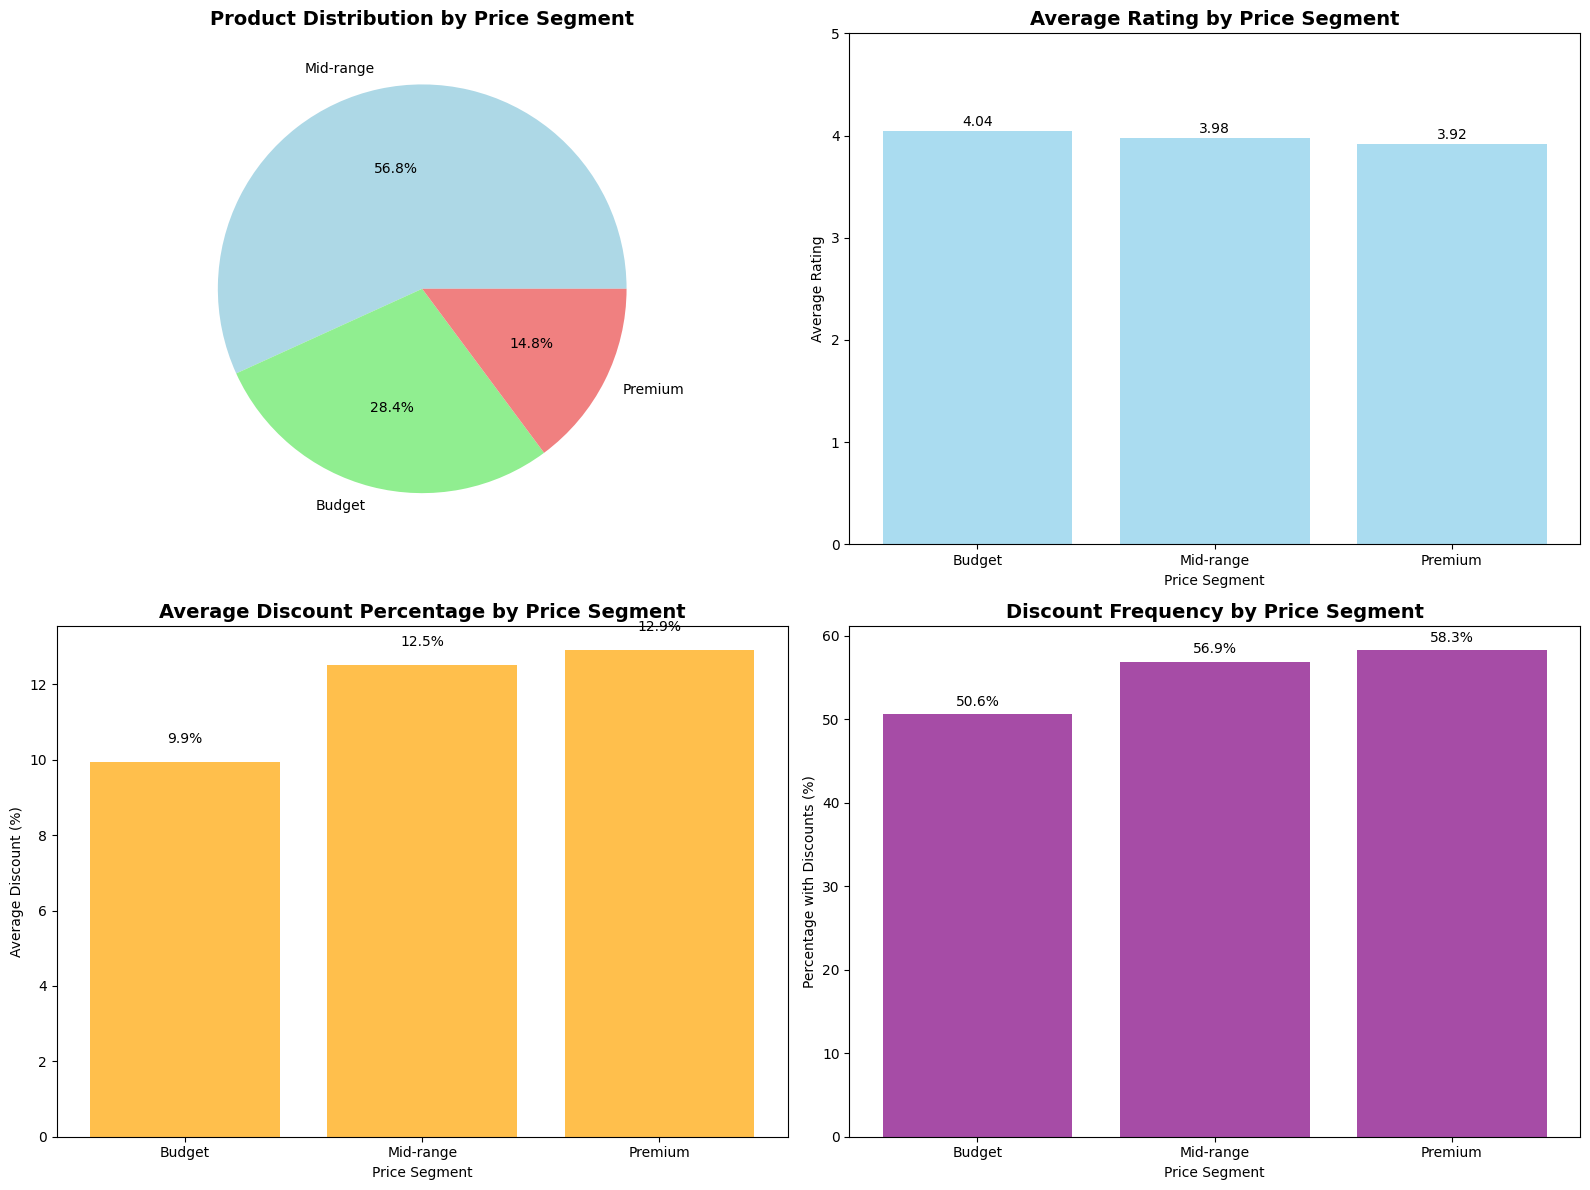


KEY INSIGHTS:
- Budget products (≤₹100): 28.37% of products, avg rating 4.04/5.0
- Mid-range products (₹100-500): 56.8% of products, avg rating 3.98/5.0
- Premium products (>₹500): 14.83% of products, avg rating 3.92/5.0
- Discount frequency: Budget 51.0%, Premium 58.0%


In [24]:
# Price segments deep dive analysis
print('PRICE SEGMENTS DEEP DIVE ANALYSIS')
print('=' * 35)

# Comprehensive analysis by price segment
segment_analysis = df.groupby('price_segment').agg({
    'sale_price': ['count', 'mean', 'min', 'max', 'std'],
    'rating': ['mean', 'median'],
    'discount_pct': ['mean', 'max'],
    'is_discounted': 'mean'
}).round(2)

print('Comprehensive Analysis by Price Segment:')
print(segment_analysis)

# Calculate percentages
segment_counts = df['price_segment'].value_counts()
segment_percentages = (segment_counts / len(df) * 100).round(2)

print(f'\nSegment Distribution:')
for segment, count in segment_counts.items():
    pct = segment_percentages[segment]
    print(f'- {segment}: {count:,} products ({pct}%)')

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Segment distribution pie chart
ax1.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'lightgreen', 'lightcoral'])
ax1.set_title('Product Distribution by Price Segment', fontsize=14, fontweight='bold')

# Average rating by segment
ratings_by_segment = df.groupby('price_segment')['rating'].mean()
ax2.bar(ratings_by_segment.index, ratings_by_segment.values, color='skyblue', alpha=0.7)
ax2.set_title('Average Rating by Price Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Price Segment')
ax2.set_ylabel('Average Rating')
ax2.set_ylim(0, 5)

# Add rating labels
for i, v in enumerate(ratings_by_segment):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center')

# Discount percentage by segment
discount_by_segment = df.groupby('price_segment')['discount_pct'].mean()
ax3.bar(discount_by_segment.index, discount_by_segment.values, color='orange', alpha=0.7)
ax3.set_title('Average Discount Percentage by Price Segment', fontsize=14, fontweight='bold')
ax3.set_xlabel('Price Segment')
ax3.set_ylabel('Average Discount (%)')

# Add discount labels
for i, v in enumerate(discount_by_segment):
    ax3.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Discount frequency by segment
discount_freq = df.groupby('price_segment')['is_discounted'].mean() * 100
ax4.bar(discount_freq.index, discount_freq.values, color='purple', alpha=0.7)
ax4.set_title('Discount Frequency by Price Segment', fontsize=14, fontweight='bold')
ax4.set_xlabel('Price Segment')
ax4.set_ylabel('Percentage with Discounts (%)')

# Add frequency labels
for i, v in enumerate(discount_freq):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
budget_rating = segment_analysis.loc['Budget', ('rating', 'mean')]
mid_rating = segment_analysis.loc['Mid-range', ('rating', 'mean')]
premium_rating = segment_analysis.loc['Premium', ('rating', 'mean')]

print(f'- Budget products (≤₹100): {segment_percentages["Budget"]}% of products, avg rating {budget_rating}/5.0')
print(f'- Mid-range products (₹100-500): {segment_percentages["Mid-range"]}% of products, avg rating {mid_rating}/5.0')
print(f'- Premium products (>₹500): {segment_percentages["Premium"]}% of products, avg rating {premium_rating}/5.0')

budget_discount = segment_analysis.loc['Budget', ('is_discounted', 'mean')] * 100
premium_discount = segment_analysis.loc['Premium', ('is_discounted', 'mean')] * 100
print(f'- Discount frequency: Budget {budget_discount:.1f}%, Premium {premium_discount:.1f}%')

In [25]:
# Overall summary of findings
print('BIGBASKET MARKET ANALYSIS - SUMMARY OF KEY FINDINGS')
print('=' * 55)

print(f'Dataset Overview:')
print(f'- Total products analyzed: {len(df):,}')
print(f'- Categories: {df["category"].nunique()}')
print(f'- Brands: {df["brand"].nunique()}')
print(f'- Average product price: ₹{df["sale_price"].mean():.2f}')
print(f'- Average product rating: {df["rating"].mean():.2f}/5.0')
print(f'- Discounted products: {df["is_discounted"].sum():,} ({df["is_discounted"].mean()*100:.1f}%)')

print(f'\nMarket Structure:')
category_counts = df['category'].value_counts()
print(f'- Largest category: {category_counts.index[0]} ({category_counts.iloc[0]:,} products)')
brand_counts = df['brand'].value_counts()
print(f'- Largest brand: {brand_counts.index[0]} ({brand_counts.iloc[0]:,} products)')

print(f'\nPricing Insights:')
price_segment_dist = df['price_segment'].value_counts(normalize=True) * 100
print(f'- Budget products (≤₹100): {price_segment_dist["Budget"]:.1f}%')
print(f'- Mid-range products (₹100-500): {price_segment_dist["Mid-range"]:.1f}%')
print(f'- Premium products (>₹500): {price_segment_dist["Premium"]:.1f}%')

print(f'\nQuality Insights:')
rating_segment_dist = df['rating_segment'].value_counts(normalize=True) * 100
print(f'- High-rated products (>4.0): {rating_segment_dist["High"]:.1f}%')
print(f'- Medium-rated products (3.0-4.0): {rating_segment_dist["Medium"]:.1f}%')
print(f'- Low-rated products (<3.0): {rating_segment_dist["Low"]:.1f}%')

print(f'\nDiscount Analysis:')
discounted = df[df['is_discounted']]
print(f'- Average discount: {discounted["discount_pct"].mean():.1f}%')
print(f'- Maximum discount: {discounted["discount_pct"].max():.1f}%')

correlation = df['sale_price'].corr(df['rating'])
print(f'\nPrice-Rating Correlation: {correlation:.3f} (weak {"positive" if correlation > 0 else "negative"})')

print(f'\nRecommendations:')
print(f'1. Focus on {category_counts.index[0]} category expansion')
print(f'2. Promote {brand_counts.index[0]} brand partnerships')
print(f'3. Optimize pricing in {price_segment_dist.idxmax()} segment')
print(f'4. Improve quality in low-rated product segments')
print(f'5. Leverage discount strategies (currently {df["is_discounted"].mean()*100:.1f}% discounted)')

BIGBASKET MARKET ANALYSIS - SUMMARY OF KEY FINDINGS
Dataset Overview:
- Total products analyzed: 27,200
- Categories: 11
- Brands: 2313
- Average product price: ₹320.95
- Average product rating: 3.99/5.0
- Discounted products: 15,046 (55.3%)

Market Structure:
- Largest category: Beauty & Hygiene (7,682 products)
- Largest brand: Fresho (638 products)

Pricing Insights:
- Budget products (≤₹100): 28.4%
- Mid-range products (₹100-500): 56.8%
- Premium products (>₹500): 14.8%

Quality Insights:
- High-rated products (>4.0): 64.2%
- Medium-rated products (3.0-4.0): 28.4%
- Low-rated products (<3.0): 7.5%

Discount Analysis:
- Average discount: 21.4%
- Maximum discount: 83.7%

Price-Rating Correlation: -0.036 (weak negative)

Recommendations:
1. Focus on Beauty & Hygiene category expansion
2. Promote Fresho brand partnerships
3. Optimize pricing in Mid-range segment
4. Improve quality in low-rated product segments
5. Leverage discount strategies (currently 55.3% discounted)
